# Sales Forecasting Using Time Series Analysis (Predictive Analytics)

## Importing required libraries

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from xgboost import XGBRegressor

## Loading dataset

In [86]:
# Loading dataset
df = pd.read_csv( "supermarket_sales.csv")
df.head()

,invoice_id,branch,city,customer_type,gender,category,unit_price,quantity,total,date,time,payment,cogs,gross_margin_percentage,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


## Exploratory Data Analysis(EDA)

In [89]:
df.isnull().sum()

invoice_id                 0
branch                     0
city                       0
customer_type              0
gender                     0
category                   0
unit_price                 0
quantity                   0
total                      0
date                       0
time                       0
payment                    0
cogs                       0
gross_margin_percentage    0
gross_income               0
rating                     0
dtype: int64

In [91]:
df.dtypes

invoice_id                  object
branch                      object
city                        object
customer_type               object
gender                      object
category                    object
unit_price                 float64
quantity                     int64
total                      float64
date                        object
time                        object
payment                     object
cogs                       float64
gross_margin_percentage    float64
gross_income               float64
rating                     float64
dtype: object

In [93]:
# Converting date column to datetime
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y')  

## Feature Engineering

In [96]:
# Extracting features from date & time
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df['hour'] = pd.to_datetime(df['time'], format='%H:%M').dt.hour

## One-hot Encoding

In [99]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Selecting numerical features
numerical_features = ['unit_price', 'quantity', 'cogs', 'gross_income', 'hour', 'day', 'month', 'year']
X = df[numerical_features]  # Define X (features)
y = df['cogs'] 

df[numerical_features] = scaler.fit_transform(df[numerical_features])

## Outlier Detection & Handling

In [102]:
from scipy.stats import skew

# Calculating skewness
skew_cogs = skew(df['cogs'])
skew_gross_income = skew(df['gross_income'])

print(f"Skewness of COGS: {skew_cogs:.4f}")
print(f"Skewness of Gross Income: {skew_gross_income:.4f}")

Skewness of COGS: 0.8912
Skewness of Gross Income: 0.8912


In [104]:
from scipy.stats.mstats import winsorize

# Appling Winsorization (capping at 1% and 99%)
df['cogs'] = winsorize(df['cogs'], limits=[0.01, 0.01])
df['gross_income'] = winsorize(df['gross_income'], limits=[0.01, 0.01])

## Trainning the model

In [115]:
# Spliting data in 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


param_grid = {
    'n_estimators': [200, 300, 400], 
    'learning_rate': [0.01, 0.03, 0.05], 
    'max_depth': [3, 4, 5],  
    'subsample': [0.6, 0.7], 
    'colsample_bytree': [0.6, 0.7],  
    'gamma': [0.1, 0.3, 0.5], 
    'reg_alpha': [0.1, 0.5],  
    'reg_lambda': [1, 3, 5]  
}

xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

grid_search = GridSearchCV(
    xgb_model, param_grid, cv=5,  
    scoring='neg_mean_absolute_error', verbose=2, n_jobs=-1
)

grid_search.fit(X_train, y_train)


best_model = grid_search.best_estimator_


Fitting 5 folds for each of 1944 candidates, totalling 9720 fits


## Data Visualization

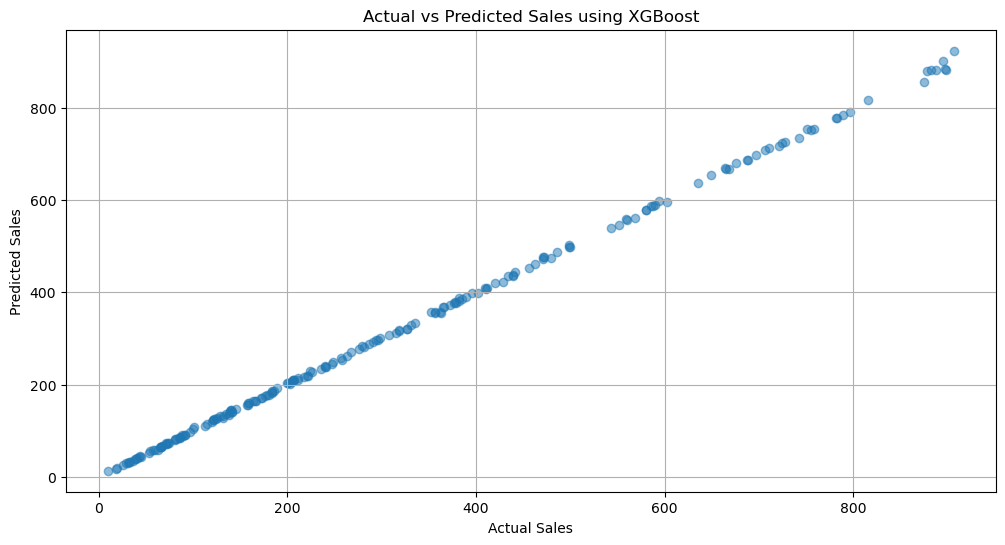

In [122]:
y_pred = best_model.predict(X_test) 

# Visualization of Actual vs Predicted Sales
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales using XGBoost")
plt.grid(True)
plt.show()

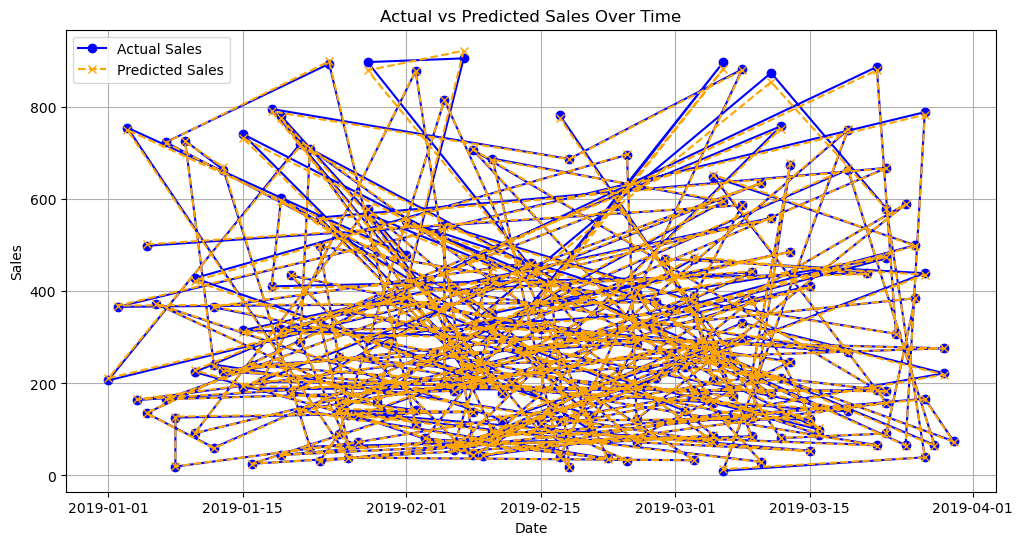

In [124]:
# Line Plot for Time Series Sales Prediction
df_test = X_test.copy()
df_test['Actual_Sales'] = y_test
df_test['Predicted_Sales'] = y_pred
df_test['date'] = df.loc[y_test.index, 'date']

# Sorting by date for visualization
df_test = df_test.sort_values('date')

# Plotting by date
plt.figure(figsize=(12, 6))
plt.plot(df['date'][:len(y_test)], y_test, label='Actual Sales', marker='o', linestyle='-', color='blue')
plt.plot(df['date'][:len(y_pred)], y_pred, label='Predicted Sales', marker='x', linestyle='--', color='orange')
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales Over Time")
plt.legend()
plt.grid()
plt.show()

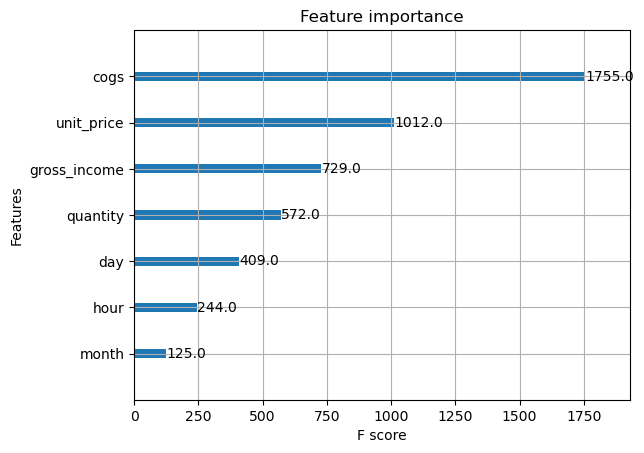

In [126]:
# Checking for important features of the model
xgb.plot_importance(best_model)
plt.show()

## Model Evaluation

In [129]:
# Evaluating best model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error: 2.41
Mean Squared Error: 13.98
R2 Score: 0.9998


In [131]:
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

print("Train R2 Score:", r2_score(y_train, y_pred_train))
print("Test R2 Score:", r2_score(y_test, y_pred_test))

Train R2 Score: 0.9999479452904141
Test R2 Score: 0.9997631338083496


In [133]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring="r2")
print("Cross-validation R2 Scores:", cv_scores)
print("Average R2 Score:", cv_scores.mean())

Cross-validation R2 Scores: [0.99957238 0.99976089 0.99973043 0.99972752 0.99967942]
Average R2 Score: 0.9996941252248615
